In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing



In [3]:
df = pd.read_excel('stc TV Data Set_T2.xlsx')
df['date_'] = pd.to_datetime(df['date_'])
df.set_index('date_', inplace=True)

In [4]:
df = df.resample('D').mean()
df['Total_watch_time_in_houres'] = df['Total_watch_time_in_houres'].interpolate(method='linear')

In [5]:
model = ExponentialSmoothing(
    df['Total_watch_time_in_houres'], 
    trend='add', 
    seasonal='add', 
    seasonal_periods=7
).fit()

forecast = model.forecast(60)

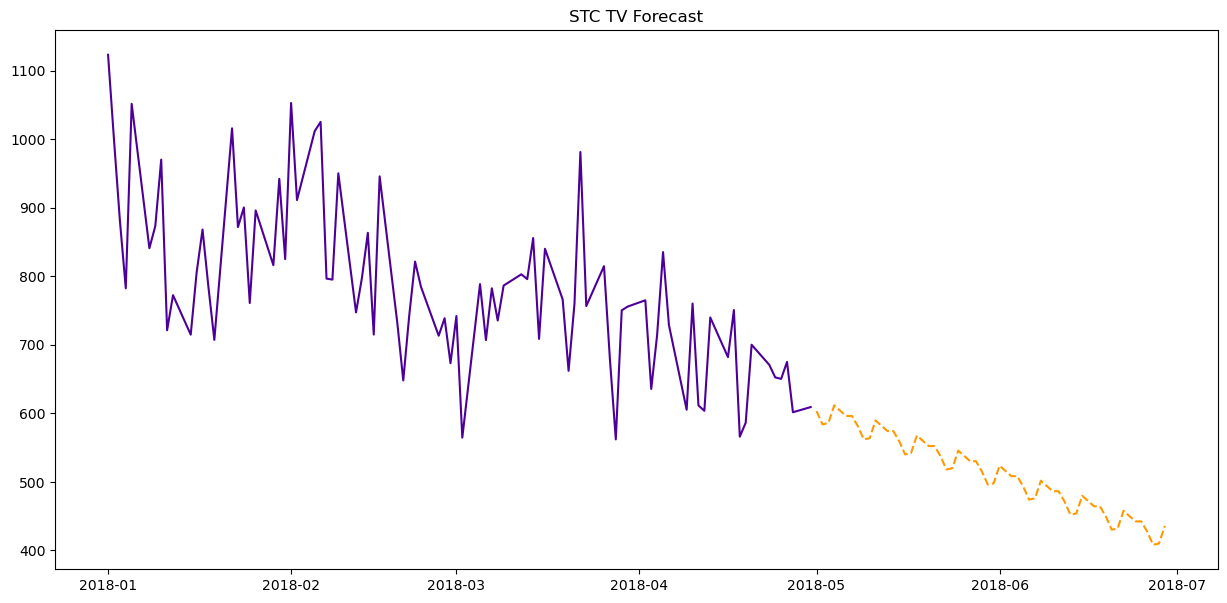

In [6]:
plt.figure(figsize=(15, 7))
plt.plot(df.index, df['Total_watch_time_in_houres'], color='#4c0099')
plt.plot(forecast.index, forecast, color='#ff9900', linestyle='--')
plt.title('STC TV Forecast')
plt.show()

In [7]:
print(forecast.sort_values(ascending=False).head(5))

2018-05-04    611.761154
2018-05-05    603.976033
2018-05-01    603.394071
2018-05-06    596.355195
2018-05-07    596.284761
dtype: float64
